# M504: Artificial Intelligence and Applications

## Individual Project

### Explanatory Data Analysis of Online Retail Data

**Student ID:** GH1057991
**Module:** M504 AI and Applications
**Institution:** Gisma University of Applied Sciences
**Repository:** https://github.com/sonu2002/M504-AI-Applications-GH1057991

## 1. Business Context

The client is a UK-based online retailer of gifts and homeware. Its customers are mainly wholesalers, with some direct consumers, which explains the large order quantities. It holds over a year of transaction data but has never analysed it systematically.

The analysis addresses which products offer the highest value, which customers are most valuable, which products are returned, what sells together, and when campaigns should run. None of this is visible in the raw transaction records, so a structured explanatory analysis is needed.

The dataset contains 541,909 transaction records for the period from December 2010 to December 2011, across eight columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country. Each row is one line item, so a single order may span several rows. The data for this report has been taken from a transactional database originally created by Chen, Sain and Guo (2012) for their work on RFM-based Customer Segmentation and was made available as part of the UCI Machine Learning Repository (full reference in the References section).

## 2. Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# load raw data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Shape: 541,909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# key dimensions
for col in ['InvoiceNo', 'StockCode', 'CustomerID', 'Country']:
    print(f"Unique {col:11s}: {df[col].nunique():,}")
print(f"Date range: {df['InvoiceDate'].min():%d %b %Y} to {df['InvoiceDate'].max():%d %b %Y}")
df[['Quantity', 'UnitPrice']].describe().round(2)

Unique InvoiceNo  : 25,900
Unique StockCode  : 4,070
Unique CustomerID : 4,372
Unique Country    : 38
Date range: 01 Dec 2010 to 09 Dec 2011


,Quantity,UnitPrice
count,541909.00,541909.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00


In [3]:
# data quality check
print("Missing values:")
print(df.isnull().sum())
print(f"Missing CustomerID: {df['CustomerID'].isnull().mean()*100:.1f}%")
for lbl, m in [('Negative qty', df['Quantity'] < 0), ('Zero price', df['UnitPrice'] == 0)]:
    print(f"{lbl}: {m.sum():,} ({m.mean()*100:.1f}%)")

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Missing CustomerID: 24.9%
Negative qty: 10,624 (2.0%)
Zero price: 2,515 (0.5%)


### 2.1 Data Exploration: Discussion

The dataset spans December 2010 to December 2011: 541,909 rows, eight columns, 25,900 invoices, 4,070 products, 4,372 identified customers and 38 countries.

Several data-quality issues require attention: CustomerID is missing for 135,080 rows (24.9 per cent), so customer-level analysis is impossible for these records. A further 1,454 rows (0.3 per cent) lack a description, 10,624 (2.0 per cent) hold negative quantities (returns or cancellations, flagged by invoice numbers beginning 'C'), and 2,515 (0.5 per cent) show a zero UnitPrice, probably promotional or adjustment items. Two rows carry a negative UnitPrice of -11,062.06, which are debt adjustments rather than sales.

Quantity ranges from -80,995 to +80,995: very large wholesale orders with matching cancellations. CustomerID is stored as a decimal because of the missing entries.

## 3. Data Preprocessing


In [4]:
retail = df.copy()
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

# Q4 needs CustomerID
dropped = retail['CustomerID'].isnull().sum()
retail = retail.dropna(subset=['CustomerID'])
retail['CustomerID'] = retail['CustomerID'].astype(int)
print(f"Dropped {dropped:,} rows with missing CustomerID; remaining: {len(retail):,}")

# derive once, reuse
retail['Revenue'] = retail['Quantity'] * retail['UnitPrice']
for f in ['Year', 'Month', 'DayOfWeek', 'Hour']:
    retail[f] = getattr(retail['InvoiceDate'].dt, f.lower())
retail['IsCancelled'] = retail['InvoiceNo'].astype(str).str.startswith('C')

# retail keeps cancellations for Q5
sales = retail[~retail['IsCancelled']]
n_cancel = retail['IsCancelled'].sum()
print(f"Cancellations: {n_cancel:,} ({n_cancel/len(retail)*100:.1f}% of rows)")
print(f"Clean dataset: {len(retail):,} rows, {retail.shape[1]} columns")

Dropped 135,080 rows with missing CustomerID; remaining: 406,829
Cancellations: 8,905 (2.2% of rows)
Clean dataset: 406,829 rows, 14 columns


### 3.1 Justification of Cleaning Decisions

The 135,080 rows with missing CustomerID values were removed, leaving 406,829 rows. This was necessary because several questions, particularly Q4, require customer-level analysis. It discards roughly a quarter of the data, and some excluded records may belong to valuable customers, so this is acknowledged as the main limitation in Section 5.

The 8,905 rows with InvoiceNo beginning 'C' and negative quantities were retained and flagged with an IsCancelled indicator, since Q5 needs them to measure returns. Revenue questions use a separate sales table excluding these, while cancellations keep negative values for return analysis.

Revenue was derived as Quantity multiplied by UnitPrice and computed once, keeping totals consistent. Year, Month, DayOfWeek and Hour were likewise extracted once rather than rebuilt for each question.

Zero-price entries were kept: at 0.5 per cent of records they do not materially distort revenue rankings.

## 4. Explanatory Data Analysis: Business Questions

Eight questions cover products, markets, timing, customers, returns, baskets and weekly patterns. The questions are designed to include a variety of pandas techniques, including grouping, resampling, datetime operations, cumulative sums, and string manipulations.

### Q1: What are the top 10 products by total revenue?

Knowing the highest-revenue products guides stock ordering and website placement.


Top 5 products by revenue (GBP):
Description
PAPER CRAFT , LITTLE BIRDIE           168470.0
REGENCY CAKESTAND 3 TIER              142593.0
WHITE HANGING HEART T-LIGHT HOLDER    100448.0
JUMBO BAG RED RETROSPOT                85221.0
MEDIUM CERAMIC TOP STORAGE JAR         81417.0


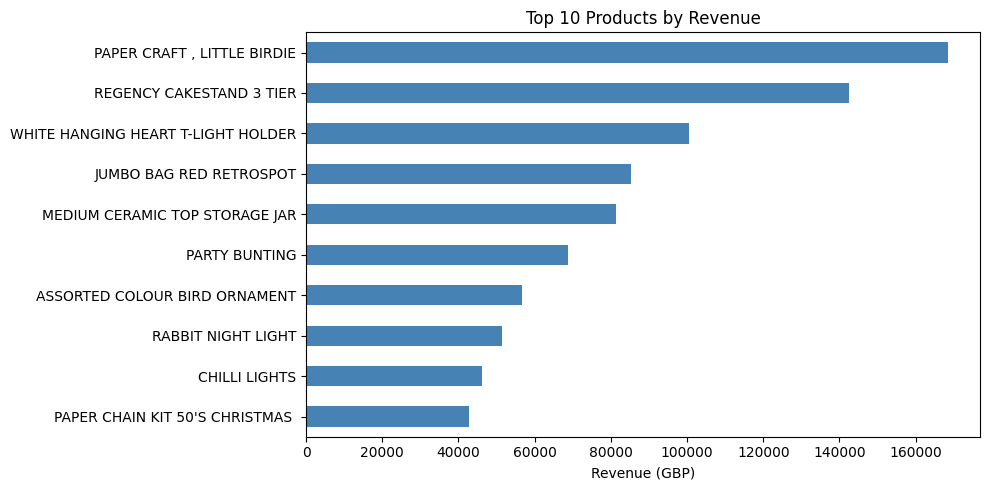

In [5]:
# real products have a 5-digit StockCode; POSTAGE, Manual etc. do not
goods = sales[sales['StockCode'].astype(str).str.match(r'^\d{5}')]
best = (goods.groupby('Description')['Revenue']
        .sum().sort_values(ascending=False).head(10))
print("Top 5 products by revenue (GBP):")
print(best.head(5).round(0).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
best.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Revenue (GBP)')
ax.set_title('Top 10 Products by Revenue')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The chart shows that PAPER CRAFT, LITTLE BIRDIE generated the highest revenue at GBP 168,470. Revenue then falls sharply among the remaining products, showing a long-tail pattern in which a few products generate most of the revenue while the long tail contributes progressively smaller amounts. Service and administrative codes were filtered out before the ranking, and only five-digit StockCodes were ranked, in order to minimise the impact of shipping and adjustment charges on the result. The retailer should keep the leading products reliably in stock and give them prominent placement on the website.

### Q2: Is the largest market also the most valuable one per customer?

Revenue alone hides how much each market is worth per account, which is what decides where sales effort should go.


UK share: 82.0% from 3,921 customers

Top 6 by revenue per customer (min 5 customers, GBP):
              revenue  customers  per_customer
Country                                       
Netherlands  285446.0          9       31716.0
Australia    138521.0          9       15391.0
Sweden        38378.0          8        4797.0
Japan         37416.0          8        4677.0
Norway        36165.0         10        3617.0
Switzerland   56444.0         21        2688.0


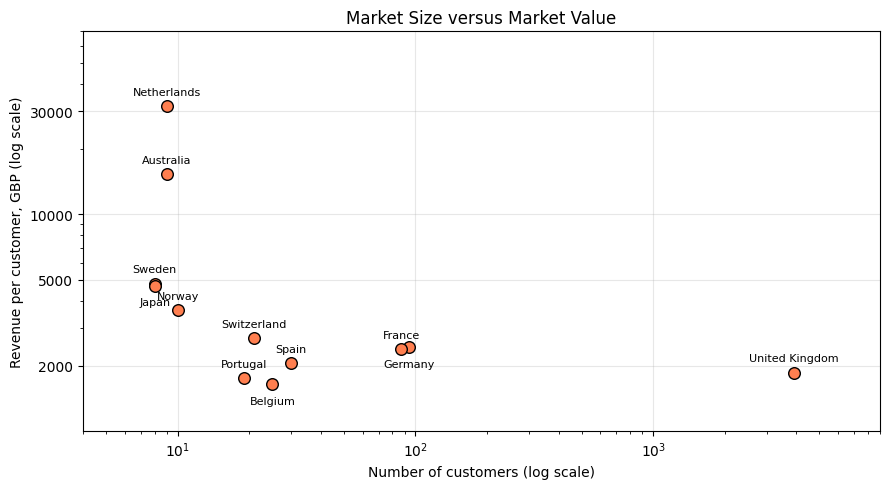

In [6]:
# market size versus value per customer
mkt = sales.groupby('Country').agg(revenue=('Revenue', 'sum'),
                                   customers=('CustomerID', 'nunique'))
mkt['per_customer'] = mkt['revenue'] / mkt['customers']
uk = mkt.loc['United Kingdom', 'revenue'] / mkt['revenue'].sum() * 100
print(f"UK share: {uk:.1f}% from {mkt.loc['United Kingdom','customers']:,} customers")
print("\nTop 6 by revenue per customer (min 5 customers, GBP):")
print(mkt[mkt['customers'] >= 5].nlargest(6, 'per_customer').round(0).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
sub = mkt[mkt['customers'] >= 5].nlargest(12, 'revenue')
ax.scatter(sub['customers'], sub['per_customer'], s=70, color='coral',
           edgecolor='black', zorder=3)
low = ['Japan', 'Germany', 'Belgium']  # nudge labels apart
for k, row in sub.iterrows():
    ax.annotate(k, (row['customers'], row['per_customer']), fontsize=8,
                xytext=(0, -14 if k in low else 8), ha='center',
                textcoords='offset points')
ax.set(xscale='log', yscale='log', xlim=(4, 9000), ylim=(1000, 70000),
       yticks=[2000, 5000, 10000, 30000],
       xlabel='Number of customers (log scale)',
       ylabel='Revenue per customer, GBP (log scale)')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.grid(alpha=0.3, zorder=0)
ax.set_title('Market Size versus Market Value')
plt.tight_layout()
plt.show()


The UK has the largest volume (82% revenue, 3,921 customers) but the lowest per-customer value (GBP 1,864) versus the Netherlands (GBP 31,716, 17x). However, only 9 accounts exist there, so a single large wholesaler could be skewing the average. Focus acquisition on proven high-value markets rather than new ones.


### Q3: What time of day sees the most ordering activity?

The best time to place adverts or send marketing emails is just before customers normally place orders.

Peak hour: 12 with 3129 orders


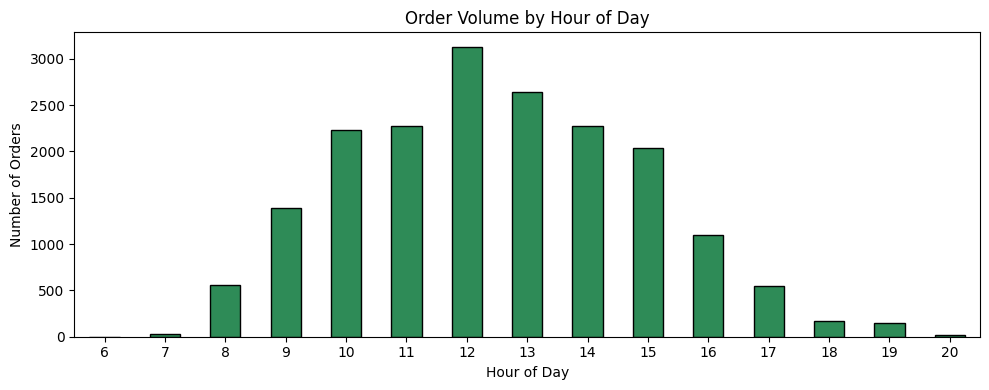

In [7]:
# orders, not line items
hourly = (sales.drop_duplicates(subset='InvoiceNo')
          .groupby('Hour')['InvoiceNo'].count())
print("Peak hour:", hourly.idxmax(), "with", hourly.max(), "orders")

fig, ax = plt.subplots(figsize=(10, 4))
hourly.plot(kind='bar', ax=ax, color='seagreen', edgecolor='black')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Orders')
ax.set_title('Order Volume by Hour of Day')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Order activity is concentrated between roughly 10:00 and 15:00, peaking at 12:00 with 3,129 orders. This business-hours pattern is typical of wholesale buyers. Emails and adverts should therefore arrive in the mid-morning, around 9:00 to 10:00, just before the ordering peak.

### Q4: Does the Pareto pattern hold - does a small share of customers drive most of the revenue?

This decides whether the client should invest in dedicated account management for a small set of large customers.

Total customers: 4,339
Customers generating 80% of revenue: 1,132 (26.1%)
Top 5 customers contribute 11.7% of revenue


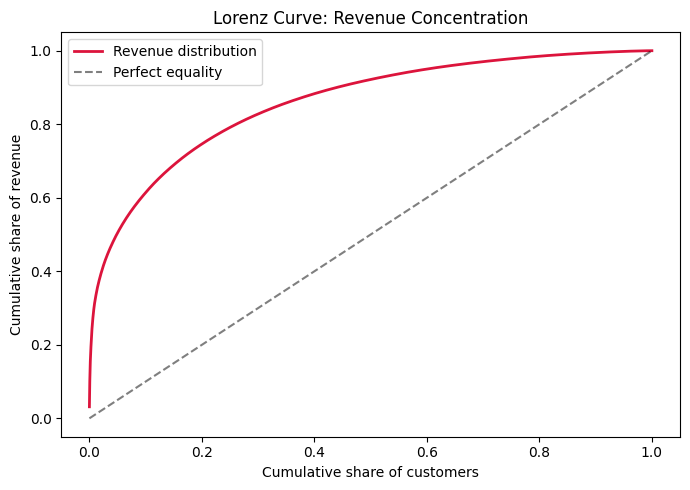

In [8]:
# Lorenz: cumulative revenue share
spend = sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
cum = spend.cumsum() / spend.sum()
pct_for_80 = (cum <= 0.80).sum() / len(cum) * 100
print(f"Total customers: {len(spend):,}")
print(f"Customers generating 80% of revenue: {(cum <= 0.80).sum():,} ({pct_for_80:.1f}%)")
print(f"Top 5 customers contribute {spend.head(5).sum()/spend.sum()*100:.1f}% of revenue")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.linspace(0, 1, len(cum)), cum.values, color='crimson', lw=2,
        label='Revenue distribution')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect equality')
ax.set_xlabel('Cumulative share of customers')
ax.set_ylabel('Cumulative share of revenue')
ax.set_title('Lorenz Curve: Revenue Concentration')
ax.legend()
plt.tight_layout()
plt.show()

The Lorenz curve shows that 26.1 per cent of purchasing customers (1,132 of 4,339) generate 80 per cent of revenue, broadly consistent with the Pareto principle (the 80-20 rule), and the top five alone account for 11.7 per cent. Revenue therefore depends heavily on a minority of accounts, which deserve dedicated account management; losing one of the largest customers would be costly.

### Q5: Which products have the highest return rates, and should the client be concerned?

High returns can signal quality or listing problems, and each returned order erases revenue.

Top 5 by return rate (%), at least 100 units sold:
Description
ROTATING SILVER ANGELS T-LIGHT HLDR    118.5
PAPER CRAFT , LITTLE BIRDIE            100.0
MEDIUM CERAMIC TOP STORAGE JAR          95.6
SET OF 3 BABUSHKA STACKING TINS         95.1
PANTRY CHOPPING BOARD                   83.1


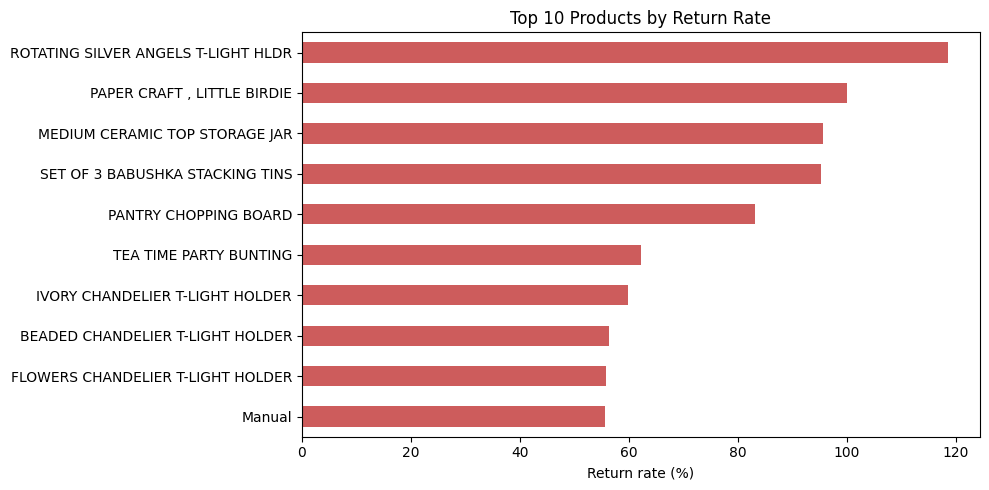

In [9]:
# returns / units sold
units_sold = sales.groupby('Description')['Quantity'].sum()
units_returned = retail[retail['IsCancelled']].groupby('Description')['Quantity'].sum().abs()
popular = units_sold[units_sold >= 100]
return_rate = (units_returned.reindex(popular.index).fillna(0) / popular * 100)
worst = return_rate.sort_values(ascending=False).head(10)
print("Top 5 by return rate (%), at least 100 units sold:")
print(worst.head(5).round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
worst.sort_values().plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('Return rate (%)')
ax.set_title('Top 10 Products by Return Rate')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The return rates are highest for ROTATING SILVER ANGELS T-LIGHT HLDR, at approximately 118.5 per cent, followed by PAPER CRAFT LITTLE BIRDIE at about 100 per cent and MEDIUM CERAMIC TOP STORAGE JAR at 95.6 per cent. A rate can exceed 100 per cent because returns were matched to same-year sales, so items sold earlier appear among this year's returns: a data-matching limitation, not impossible behaviour. Products with return rates above roughly 50 per cent should be reviewed for potential quality issues, listing accuracy, or ordering errors. However, the data does not record the reason for each return, so the cause cannot be confirmed.

### Q6: Which products are most often bought together in the same order?

Pairs that recur across baskets indicate where bundles, "complete the set" prompts and cross-sell placements will work.


Baskets analysed: 6,592
Top 3 pairs:
  106 x  GREEN REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER 
  94 x  GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER
  93 x  ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKELIKE RED 


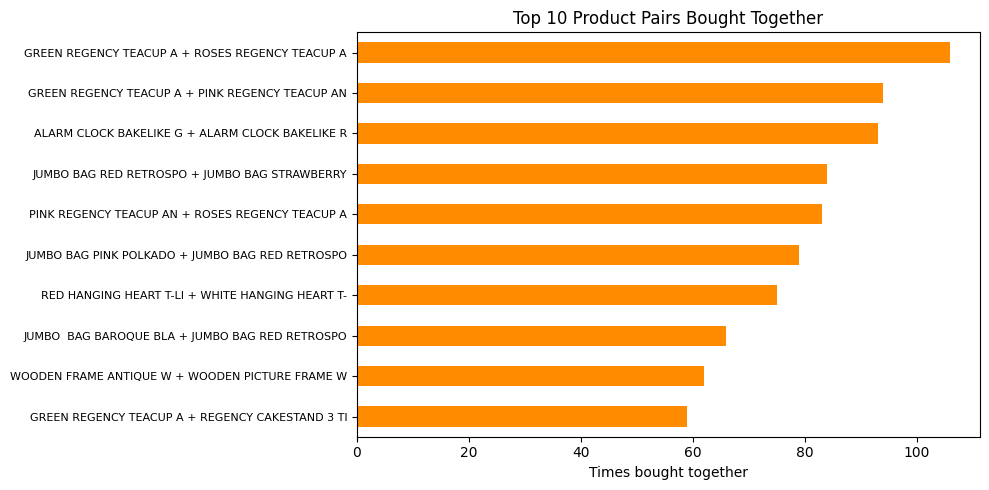

In [10]:
# co-occurrence of products within the same invoice
baskets = (goods.groupby('InvoiceNo')['Description']
           .apply(lambda x: sorted(set(x))))
baskets = baskets[baskets.str.len().between(2, 12)]
pairs = Counter()
for items in baskets:
    pairs.update(combinations(items, 2))
top = pd.Series(pairs).sort_values(ascending=False).head(10)
print(f"Baskets analysed: {len(baskets):,}")
print("Top 3 pairs:")
for (a, b), n in top.head(3).items():
    print(f"  {n} x  {a} + {b}")

fig, ax = plt.subplots(figsize=(10, 5))
top.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_yticklabels([f"{a[:22]} + {b[:22]}" for a, b in top.sort_values().index],
                   fontsize=8)
ax.set_xlabel('Times bought together')
ax.set_title('Top 10 Product Pairs Bought Together')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Top co-purchase items are colour/design variations on the same product and not different items, as seen in the basket-pair analysis (n = 6,592): Green and Roses Regency teacup, Green and Pink Regency teacup, Green and Red alarm clock, and Red Retrospot and Strawberry jumbo bag.

This implies that customers are purchasing colour sets, not complementary products, which could imply bundle offers, "complete the set" messaging and all colours in the same stocking location.


### Q7: What is the average order value and how many items are bought per order?

Typical order value sets thresholds for free shipping or volume discounts that can increase basket size.

Strongest month: Nov 2011 at GBP 1,161,817
Number of orders:      18,536
Mean order value:      GBP 480.76
Median order value:    GBP 303.02
Mean items per order:  279.5


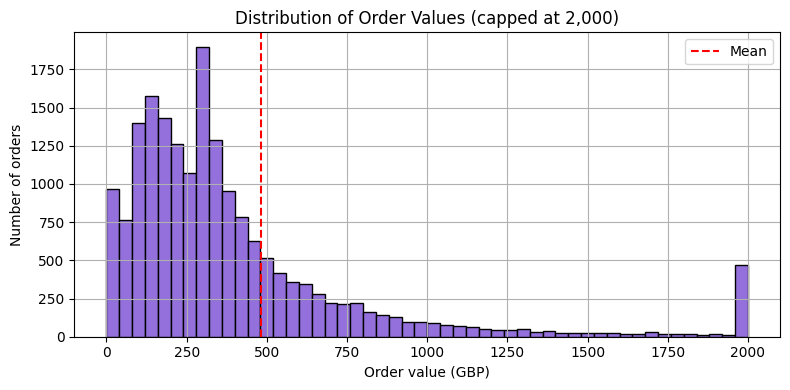

In [11]:
# line items to order level
orders = sales.groupby('InvoiceNo').agg(
    total_revenue=('Revenue', 'sum'),
    total_items=('Quantity', 'sum'),
    unique_products=('StockCode', 'nunique'))

peak = sales.set_index('InvoiceDate').resample('M')['Revenue'].sum()
print(f"Strongest month: {peak.idxmax():%b %Y} at GBP {peak.max():,.0f}")
print(f"Number of orders:      {len(orders):,}")
print(f"Mean order value:      GBP {orders['total_revenue'].mean():,.2f}")
print(f"Median order value:    GBP {orders['total_revenue'].median():,.2f}")
print(f"Mean items per order:  {orders['total_items'].mean():.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
orders['total_revenue'].clip(upper=2000).hist(bins=50, ax=ax,
    color='mediumpurple', edgecolor='black')
ax.axvline(orders['total_revenue'].mean(), color='red', linestyle='--', label='Mean')
ax.set_xlabel('Order value (GBP)')
ax.set_ylabel('Number of orders')
ax.set_title('Distribution of Order Values (capped at 2,000)')
ax.legend()
plt.tight_layout()
plt.show()

The mean order value is GBP 480.76, while the median order value is GBP 303.02. The gap between them shows a few very large wholesale orders pulling the mean up, making the median the more representative measure of a typical order. The mean of 279.5 items per order confirms a wholesale customer base. Setting free-shipping thresholds or volume discounts slightly above the typical order value could push customers towards larger orders.

### Q8: Do weekends perform differently from weekdays?

Weekend patterns affect staffing decisions and whether weekend consumer promotions are worth testing.

Weekday: 64.2 orders/day, GBP 31,839/day
Weekend: 43.4 orders/day, GBP 15,850/day


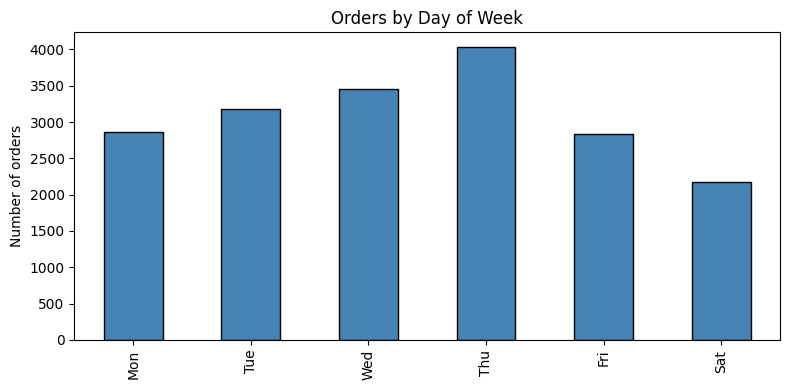

In [12]:
# per trading day
dates = pd.Series(retail['InvoiceDate'].dt.date.unique())
n_we = dates.apply(lambda d: d.weekday() in [5, 6]).sum()
is_we = sales['DayOfWeek'].isin([5, 6])
for label, m, nd in [('Weekday', ~is_we, len(dates) - n_we), ('Weekend', is_we, n_we)]:
    g = sales[m]
    print(f"{label}: {g['InvoiceNo'].nunique()/nd:.1f} orders/day, GBP {g['Revenue'].sum()/nd:,.0f}/day")

daily = sales.drop_duplicates(subset='InvoiceNo').groupby('DayOfWeek')['InvoiceNo'].count()
daily.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][:len(daily)]
fig, ax = plt.subplots(figsize=(8, 4))
daily.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_ylabel('Number of orders')
ax.set_title('Orders by Day of Week')
plt.tight_layout()
plt.show()

Activity is far higher on weekdays (64.2 orders and GBP 31,839 per day) than at weekends (43.4 orders and GBP 15,850 per day), consistent with the business-hours pattern identified in Q3. Staffing and customer support could therefore be reduced at weekends. Weekend-only promotions remain worth testing as a low-cost way to reach the smaller retail segment.

## 5. Discussion, Limitations and Recommendations

The analysis directly addressed the following varied business questions, four of which illustrate the range of techniques applied: What is the highest month of the year for revenue? November was determined to have approximately GBP 1.16 million revenue; What percentage of the customers contribute to 80 per cent of the revenue? A cumulative sum identified 26.1 per cent of customers contributing 80 per cent of the revenue; How many transactions were cancellations? pandas string operations identified 8,905 cancelled transactions by their invoice prefix; What is the highest time of day for transactions? pandas datetime features identified 12 noon as the highest time of day for transactions. All data quality concerns, especially the lack of customer IDs and return matching, were addressed openly.

The key findings share a single common thread: the business is concentrated across three independent axes, each a form of structural vulnerability. A small group of best products, one dominant market and a few high value customers hold a disproportionate share of turnover - with a stock out on a key product, a downturn in the UK market or the churn of a high value customer, the business would be vulnerable to a significant loss of turnover. Demand concentrates in working hours and weekdays, peaking in November, as expected in wholesale. This is further confirmed by the difference between the mean and median order value, with a few large wholesale orders skewing the average order value upwards. High returns on some products mark a further area for attention.

These results carry limitations. Analysing only identified customers removed 24.9 per cent of rows. No cost or margin data is held, so high revenue cannot be read as high profit. Only one year is covered, and customer demographics extend no further than country. Return reasons are also not recorded, and returns were matched against same-year sales, so items sold earlier may appear among current returns.

The business should protect key accounts with dedicated account management and prepare for the Q4 demand rise from October, ahead of the November peak. Products returning above 50 per cent should be reviewed for quality, listing and ordering problems. Mid-morning weekday email campaigns should be tested against the observed demand peak. Weekend promotions and European expansion offer low-risk experiments to test the retail and geographic opportunities.

## 6. References

Chen, D., Sain, S.L. and Guo, K. (2012) 'Data mining for the online retail industry: a case study of RFM model-based customer segmentation using data mining', Journal of Database Marketing and Customer Strategy Management, 19(3), pp. 197-208.

Dua, D. and Graff, C. (2019) UCI Machine Learning Repository: Online Retail Dataset. Irvine, CA: University of California. Available at: https://archive.ics.uci.edu/ml/datasets/Online+Retail (Accessed: 30 August 2026).